# Model-Agnostic Object Detection Evaluation

Evaluates any detection model given ground-truth annotations and a predictions file.

## Inputs
- **GT annotations** — COCO-format JSON (`_annotations.coco.json`)
- **Images directory** — folder containing the image files
- **Predictions file** — COCO results JSON: `[{"image_id", "category_id", "bbox": [x,y,w,h], "score"}, ...]`

## Contents
1. [Setup](#1-setup)
2. [Confusion Matrix](#2-confusion-matrix) — IoU-based matching, per-class precision/recall/F1
3. [FP / FN Analysis](#3-fp--fn-analysis) — wrong-class crops, FP/FN crop samples, FP/FN full images
4. [Object Size Analysis](#4-object-size-analysis) — TP/FP/FN breakdown by bounding-box area
5. [Object Location Analysis](#5-object-location-analysis) — spatial 3×3 grid heatmaps of error rates
6. [Scene Condition Analysis](#6-scene-condition-analysis) — LARS-specific: performance by scene/lighting/waves (optional)

## 1. Setup

In [1]:
from pathlib import Path
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
import supervision as sv

# ── Configuration ─────────────────────────────────────────────────────────────
# Ground-truth COCO annotation JSON
GT_ANNOTATIONS   = Path("../Data/lars_processed/test/_annotations.coco.json")

# Directory containing the image files referenced in the annotation JSON
IMAGES_DIR       = Path("../Data/lars_processed/test/images")

# Predictions in COCO results format:
#   [{"image_id": int, "category_id": int, "bbox": [x, y, w, h], "score": float}, ...]
# category_id must match the IDs in GT_ANNOTATIONS.
# Set to None to skip prediction-based sections (GT-only stats still work).
PREDICTIONS_FILE = Path("../runs/optuna_relabeled_lb/trial_004/predictions_test.json")

# Directory where output figures are saved
SAVE_DIR         = Path("../runs/optuna_relabeled_lb/trial_004")

THRESHOLD  = 0.4   # confidence threshold applied when loading predictions
IOU_THRESH = 0.5   # IoU threshold for TP/FP matching

random.seed(4)
np.random.seed(4)

In [2]:
# Load ground-truth annotations
ann = json.load(open(GT_ANNOTATIONS))

img_meta     = {img["id"]: img for img in ann["images"]}
ann_by_img   = {}
for a in ann["annotations"]:
    ann_by_img.setdefault(a["image_id"], []).append(a)

categories  = ann["categories"]
CLASS_IDS   = [c["id"]   for c in categories]
CLASS_NAMES = [c["name"] for c in categories]
id_to_idx   = {cid: i for i, cid in enumerate(CLASS_IDS)}
N_CLASSES   = len(CLASS_IDS)

print(f"Dataset: {len(ann['images'])} images, {len(ann['annotations'])} GT annotations")
print(f"Classes ({N_CLASSES}):")
for cid, name in zip(CLASS_IDS, CLASS_NAMES):
    count = sum(1 for a in ann["annotations"] if a["category_id"] == cid)
    print(f"  [{cid:2d}] {name:<20} {count:4d} instances")

Dataset: 503 images, 1560 GT annotations
Classes (8):
  [11] Boat/ship             964 instances
  [12] Row boats              72 instances
  [13] Paddle board           30 instances
  [14] Buoy                  294 instances
  [15] Swimmer                86 instances
  [16] Animal                 14 instances
  [17] Float                   4 instances
  [19] Other                  96 instances


---
## 2. Confusion Matrix

For every image:
1. Predictions are matched to GT boxes by **IoU ≥ IOU_THRESH** (greedy, highest-confidence first).
2. Matched pair with same class → **TP**; different class → **wrong-class** entry.
3. Unmatched GT → **FN** (mapped to *Background* column).
4. Unmatched prediction → **FP** (mapped to *Background* row).

Matrix rows = actual (GT), columns = predicted.

In [3]:
# ── Helper functions ──────────────────────────────────────────────────────────

def box_iou(a, b):
    """IoU between two boxes in xyxy format."""
    xi1, yi1 = max(a[0], b[0]), max(a[1], b[1])
    xi2, yi2 = min(a[2], b[2]), min(a[3], b[3])
    inter    = max(0.0, xi2 - xi1) * max(0.0, yi2 - yi1)
    area_a   = (a[2] - a[0]) * (a[3] - a[1])
    area_b   = (b[2] - b[0]) * (b[3] - b[1])
    union    = area_a + area_b - inter
    return inter / union if union > 0 else 0.0


def match_detections(pred_det, gt_det, iou_thresh=0.5):
    """
    Greedy IoU matching (predictions sorted by descending confidence).

    Returns
    -------
    matched  : list of (gt_class, pred_class, pred_score, pred_box, gt_box)
    fn_list  : list of (gt_box, gt_class)    unmatched GT objects
    fp_list  : list of (pred_box, pred_class, pred_score)   spurious predictions
    """
    pred_boxes   = pred_det.xyxy       if len(pred_det) > 0 else np.empty((0, 4))
    pred_classes = pred_det.class_id   if len(pred_det) > 0 else np.array([], dtype=int)
    pred_scores  = (pred_det.confidence
                    if pred_det.confidence is not None and len(pred_det) > 0
                    else np.ones(len(pred_det)))
    gt_boxes     = gt_det.xyxy         if len(gt_det) > 0 else np.empty((0, 4))
    gt_classes   = gt_det.class_id     if len(gt_det) > 0 else np.array([], dtype=int)

    if len(pred_boxes) == 0:
        return [], [(gt_boxes[i], gt_classes[i]) for i in range(len(gt_boxes))], []
    if len(gt_boxes) == 0:
        return [], [], [(pred_boxes[i], pred_classes[i], pred_scores[i])
                        for i in range(len(pred_boxes))]

    order        = np.argsort(-pred_scores)
    pred_boxes   = pred_boxes[order]
    pred_classes = pred_classes[order]
    pred_scores  = pred_scores[order]

    matched_gt, matched_pred = {}, {}
    for pi, (pb, pc, ps) in enumerate(zip(pred_boxes, pred_classes, pred_scores)):
        best_iou, best_gi = iou_thresh, -1
        for gi in range(len(gt_boxes)):
            if gi in matched_gt:
                continue
            iou = box_iou(pb, gt_boxes[gi])
            if iou > best_iou:
                best_iou, best_gi = iou, gi
        if best_gi >= 0:
            matched_gt[best_gi]  = pi
            matched_pred[pi]     = best_gi

    matched = [
        (gt_classes[gi], pred_classes[pi], pred_scores[pi], pred_boxes[pi], gt_boxes[gi])
        for gi, pi in matched_gt.items()
    ]
    fn_list = [(gt_boxes[i], gt_classes[i])
               for i in range(len(gt_boxes)) if i not in matched_gt]
    fp_list = [(pred_boxes[i], pred_classes[i], pred_scores[i])
               for i in range(len(pred_boxes)) if i not in matched_pred]

    return matched, fn_list, fp_list

In [4]:
# Load predictions from COCO results file and build sv.Detections per image
# Expected format: [{"image_id": int, "category_id": int, "bbox": [x,y,w,h], "score": float}, ...]
# category_id should use the same IDs as in GT_ANNOTATIONS.

if PREDICTIONS_FILE is None or not Path(PREDICTIONS_FILE).exists():
    raise FileNotFoundError(
        f"Predictions file not found: {PREDICTIONS_FILE}\n"
        "Export your model's predictions in COCO results format and set PREDICTIONS_FILE above."
    )

raw_preds = json.load(open(PREDICTIONS_FILE))
raw_preds = [p for p in raw_preds if p["score"] >= THRESHOLD]

preds_by_img = {}
for p in raw_preds:
    preds_by_img.setdefault(p["image_id"], []).append(p)

img_id_order  = list(img_meta.keys())
all_gt_dets   = []
all_pred_dets = []

for img_id in img_id_order:
    # Ground truth
    gt_anns = ann_by_img.get(img_id, [])
    if gt_anns:
        gt_xyxy = np.array([[a["bbox"][0], a["bbox"][1],
                              a["bbox"][0] + a["bbox"][2],
                              a["bbox"][1] + a["bbox"][3]] for a in gt_anns], dtype=float)
        gt_cids = np.array([a["category_id"] for a in gt_anns], dtype=int)
    else:
        gt_xyxy = np.empty((0, 4), dtype=float)
        gt_cids = np.array([], dtype=int)
    all_gt_dets.append(sv.Detections(xyxy=gt_xyxy, class_id=gt_cids))

    # Predictions
    img_preds = preds_by_img.get(img_id, [])
    if img_preds:
        pred_xyxy   = np.array([[p["bbox"][0], p["bbox"][1],
                                  p["bbox"][0] + p["bbox"][2],
                                  p["bbox"][1] + p["bbox"][3]] for p in img_preds], dtype=float)
        pred_cids   = np.array([p["category_id"] for p in img_preds], dtype=int)
        pred_scores = np.array([p["score"]        for p in img_preds], dtype=float)
    else:
        pred_xyxy   = np.empty((0, 4), dtype=float)
        pred_cids   = np.array([], dtype=int)
        pred_scores = np.array([], dtype=float)
    all_pred_dets.append(sv.Detections(xyxy=pred_xyxy, class_id=pred_cids, confidence=pred_scores))

total_preds = sum(len(p) for p in all_pred_dets)
print(f"Loaded {len(raw_preds)} predictions above threshold={THRESHOLD}")
print(f"Images with ≥1 prediction: {len(preds_by_img)} / {len(img_id_order)}")
print(f"Total predictions in memory: {total_preds}")

Loaded 1338 predictions above threshold=0.4
Images with ≥1 prediction: 394 / 503
Total predictions in memory: 1338


In [5]:
# Predictions use original COCO category IDs (same as GT_ANNOTATIONS)
def cls_name(cid):
    idx = id_to_idx.get(int(cid), -1)
    return CLASS_NAMES[idx] if 0 <= idx < N_CLASSES else str(cid)

# confusion matrix: rows = GT class (0..N-1), cols = predicted class (0..N-1),
# extra row/col index N = Background (FP/FN)
cm = np.zeros((N_CLASSES + 1, N_CLASSES + 1), dtype=int)

wrong_class_examples = []   # (img_path, pred_box, pred_cls, pred_score, gt_box, gt_cls)
fp_by_image          = {}   # img_path -> [(pred_box, pred_cls, score), ...]
fn_by_image          = {}   # img_path -> [(gt_box,  gt_cls), ...]

# Also collect per-instance records for size/location analyses
tp_records = []   # {gt_cls_idx, pred_cls_idx, gt_box, pred_box, img_id}
fp_records = []   # {pred_cls_idx, pred_box, pred_score, img_id}
fn_records = []   # {gt_cls_idx,  gt_box, img_id}

for i, img_id in enumerate(img_id_order):
    img_path = IMAGES_DIR / img_meta[img_id]["file_name"]
    matched, fn_list, fp_list = match_detections(
        all_pred_dets[i], all_gt_dets[i], IOU_THRESH
    )

    for gc, pc, ps, pb, gb in matched:
        gi = id_to_idx.get(int(gc), -1)
        pi = id_to_idx.get(int(pc), -1)
        if gi >= 0 and pi >= 0:
            cm[gi, pi] += 1
            tp_records.append(dict(gt_cls=gi, pred_cls=pi, gt_box=gb, pred_box=pb, img_id=img_id))
            if gi != pi:
                wrong_class_examples.append((img_path, pb, pc, ps, gb, gc))

    for gb, gc in fn_list:
        gi = id_to_idx.get(int(gc), -1)
        if gi >= 0:
            cm[gi, N_CLASSES] += 1
            fn_records.append(dict(gt_cls=gi, gt_box=gb, img_id=img_id))
    if fn_list:
        fn_by_image[img_path] = fn_list

    for pb, pc, ps in fp_list:
        pi = id_to_idx.get(int(pc), -1)
        if pi >= 0:
            cm[N_CLASSES, pi] += 1
            fp_records.append(dict(pred_cls=pi, pred_box=pb, pred_score=ps, img_id=img_id))
    if fp_list:
        fp_by_image[img_path] = fp_list

print(f"Total GT objects      : {cm[:-1, :].sum()}")
print(f"True positives (TP)   : {np.diag(cm[:N_CLASSES, :N_CLASSES]).sum()}")
print(f"Wrong-class           : {cm[:N_CLASSES, :N_CLASSES].sum() - np.diag(cm[:N_CLASSES, :N_CLASSES]).sum()}")
print(f"False negatives (FN)  : {cm[:N_CLASSES, N_CLASSES].sum()}")
print(f"False positives (FP)  : {cm[N_CLASSES, :N_CLASSES].sum()}")

Total GT objects      : 1560
True positives (TP)   : 958
Wrong-class           : 54
False negatives (FN)  : 548
False positives (FP)  : 326


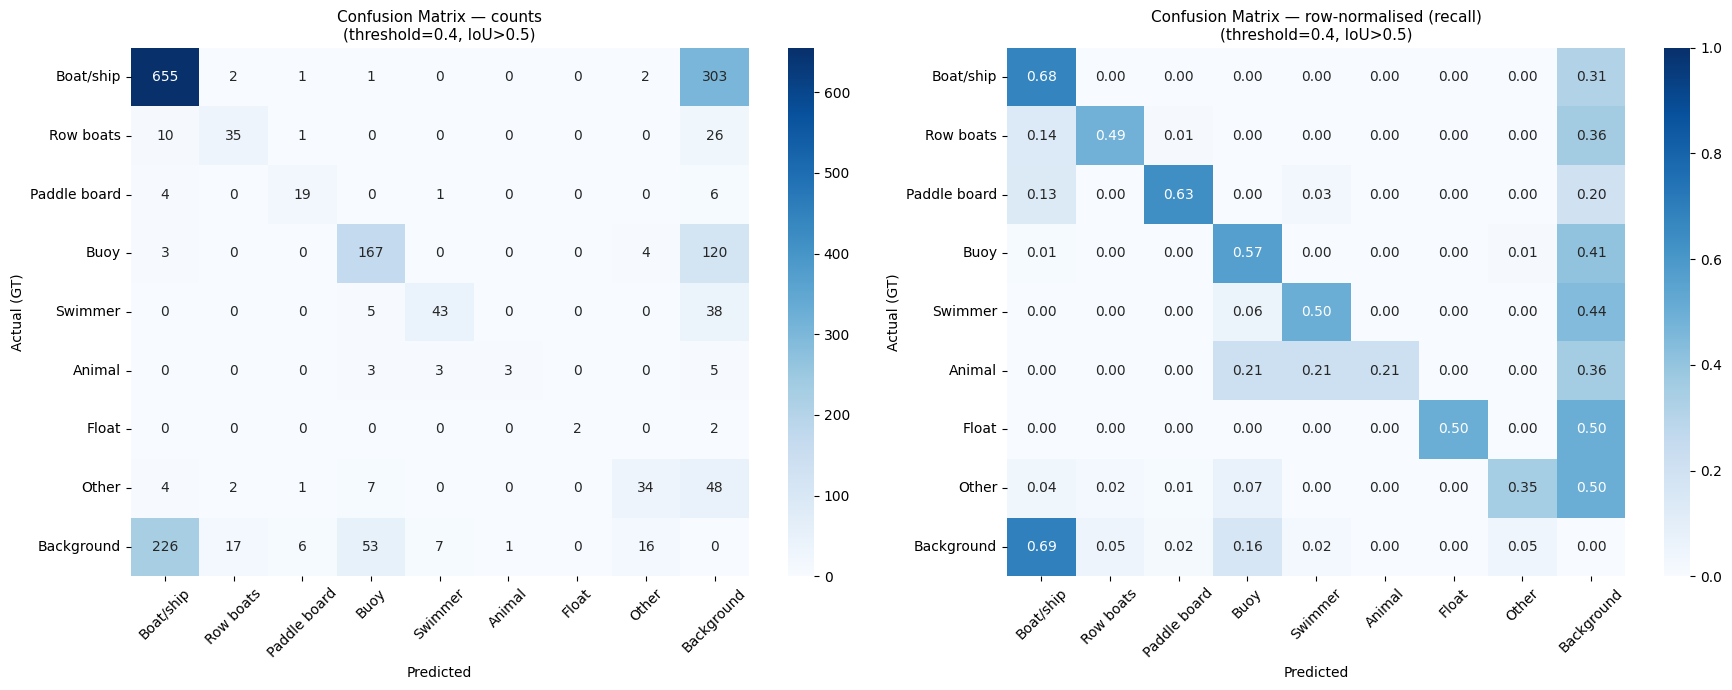

In [6]:
labels_bg = CLASS_NAMES + ["Background"]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_bg, yticklabels=labels_bg, ax=ax)
ax.set_title(f"Confusion Matrix — counts\n(threshold={THRESHOLD}, IoU>{IOU_THRESH})", fontsize=11)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual (GT)")
ax.tick_params(axis="x", rotation=45)

cm_norm  = cm.astype(float)
row_sums = cm_norm.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
cm_norm /= row_sums

ax = axes[1]
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=labels_bg, yticklabels=labels_bg, ax=ax, vmin=0, vmax=1)
ax.set_title(f"Confusion Matrix — row-normalised (recall)\n(threshold={THRESHOLD}, IoU>{IOU_THRESH})", fontsize=11)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual (GT)")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
SAVE_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(SAVE_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
# Per-class precision and recall derived from the confusion matrix
print(f"{'Class':<20} {'TP':>5} {'FN':>5} {'FP':>5} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("-" * 65)
for i, name in enumerate(CLASS_NAMES):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp    # all GT i not predicted as i
    fp = cm[:, i].sum() - tp    # all predictions of i that aren't GT i
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    print(f"{name:<20} {tp:>5} {fn:>5} {fp:>5} {prec:>10.3f} {rec:>8.3f} {f1:>8.3f}")

Class                   TP    FN    FP  Precision   Recall       F1
-----------------------------------------------------------------
Boat/ship              655   309   247      0.726    0.679    0.702
Row boats               35    37    21      0.625    0.486    0.547
Paddle board            19    11     9      0.679    0.633    0.655
Buoy                   167   127    69      0.708    0.568    0.630
Swimmer                 43    43    11      0.796    0.500    0.614
Animal                   3    11     1      0.750    0.214    0.333
Float                    2     2     0      1.000    0.500    0.667
Other                   34    62    22      0.607    0.354    0.447


In [8]:
# mAP — always uses ALL predictions regardless of THRESHOLD so the full PR
# curve is available. THRESHOLD only affects the confusion matrix / visuals.
EXCLUDE_CLASSES = ["Float"]   # tiny / unreliable classes to drop from weighted mAP

def to_0idx(xyxy, cids, scores=None):
    mapped = np.array([id_to_idx.get(int(c), -1) for c in cids], dtype=int)
    m = mapped >= 0
    conf = scores[m] if scores is not None else np.ones(m.sum())
    return sv.Detections(xyxy=xyxy[m], class_id=mapped[m], confidence=conf)

# GT detections (0-indexed, no scores needed)
gt_sv = []
for d in all_gt_dets:
    if len(d) == 0:
        gt_sv.append(sv.Detections(xyxy=np.empty((0,4),dtype=float),
                                   class_id=np.array([],dtype=int)))
    else:
        mapped = np.array([id_to_idx.get(int(c), -1) for c in d.class_id], dtype=int)
        m = mapped >= 0
        gt_sv.append(sv.Detections(xyxy=d.xyxy[m], class_id=mapped[m]))

# Predictions — reload without any score filter
_all_raw, _by_img = json.load(open(PREDICTIONS_FILE)), {}
for p in _all_raw:
    _by_img.setdefault(p["image_id"], []).append(p)

pred_sv_all = []
for img_id in img_id_order:
    ps = _by_img.get(img_id, [])
    if ps:
        xyxy   = np.array([[p["bbox"][0], p["bbox"][1],
                            p["bbox"][0]+p["bbox"][2],
                            p["bbox"][1]+p["bbox"][3]] for p in ps], dtype=float)
        cids   = np.array([p["category_id"] for p in ps], dtype=int)
        scores = np.array([p["score"]        for p in ps], dtype=float)
        pred_sv_all.append(to_0idx(xyxy, cids, scores))
    else:
        pred_sv_all.append(sv.Detections(xyxy=np.empty((0,4),dtype=float),
                                         class_id=np.array([],dtype=int),
                                         confidence=np.array([],dtype=float)))

# ── Standard mAP ─────────────────────────────────────────────────────────────
metric = sv.metrics.MeanAveragePrecision()
metric.update(pred_sv_all, gt_sv)
res = metric.compute()

ap_map = {int(cls): res.ap_per_class[i, 0] for i, cls in enumerate(res.matched_classes)}

print(f"mAP@50     = {res.map50:.4f}   (mean over all {N_CLASSES} classes, equal weight)")
print(f"mAP@75     = {res.map75:.4f}")
print(f"mAP@50:95  = {res.map50_95:.4f}")

# ── mAP excluding unreliable / tiny classes ───────────────────────────────────
excl_idxs  = {CLASS_NAMES.index(c) for c in EXCLUDE_CLASSES if c in CLASS_NAMES}
incl_mask  = np.array([int(cls) not in excl_idxs for cls in res.matched_classes])
if incl_mask.any():
    map50_excl = res.ap_per_class[incl_mask, 0].mean()
    excl_str   = ", ".join(EXCLUDE_CLASSES)
    print(f"mAP@50     = {map50_excl:.4f}   (excl. {excl_str})")

# ── Class-agnostic mAP (object vs. background, ignores category) ──────────────
def strip_class(dets):
    if len(dets) == 0:
        return sv.Detections(xyxy=np.empty((0,4),dtype=float),
                             class_id=np.array([],dtype=int),
                             confidence=dets.confidence if dets.confidence is not None else None)
    conf = dets.confidence if dets.confidence is not None else np.ones(len(dets))
    return sv.Detections(xyxy=dets.xyxy,
                         class_id=np.zeros(len(dets), dtype=int),
                         confidence=conf)

metric_agn = sv.metrics.MeanAveragePrecision()
metric_agn.update([strip_class(d) for d in pred_sv_all],
                  [strip_class(d) for d in gt_sv])
res_agn = metric_agn.compute()
print(f"mAP@50     = {res_agn.map50:.4f}   (class-agnostic: object vs. background)")

# ── Per-class AP table ────────────────────────────────────────────────────────
print(f"\n{'Class':<20} {'#GT':>5} {'AP@50':>8}  {'note':}")
print("-" * 45)
for idx, name in enumerate(CLASS_NAMES):
    gt_count = sum(1 for a in ann["annotations"] if a["category_id"] == CLASS_IDS[idx])
    ap       = ap_map.get(idx, float("nan"))
    note     = " ← excluded" if name in EXCLUDE_CLASSES else ""
    print(f"{name:<20} {gt_count:>5} {ap:>8.4f}  {note}")

mAP@50     = 0.5628   (mean over all 8 classes, equal weight)
mAP@75     = 0.3435
mAP@50:95  = 0.3220
mAP@50     = 0.5706   (excl. Float)
mAP@50     = 0.6844   (class-agnostic: object vs. background)

Class                  #GT    AP@50  note
---------------------------------------------
Boat/ship              964   0.7112  
Row boats               72   0.5458  
Paddle board            30   0.8323  
Buoy                   294   0.6062  
Swimmer                 86   0.5752  
Animal                  14   0.3423  
Float                    4   0.5088   ← excluded
Other                   96   0.3809  


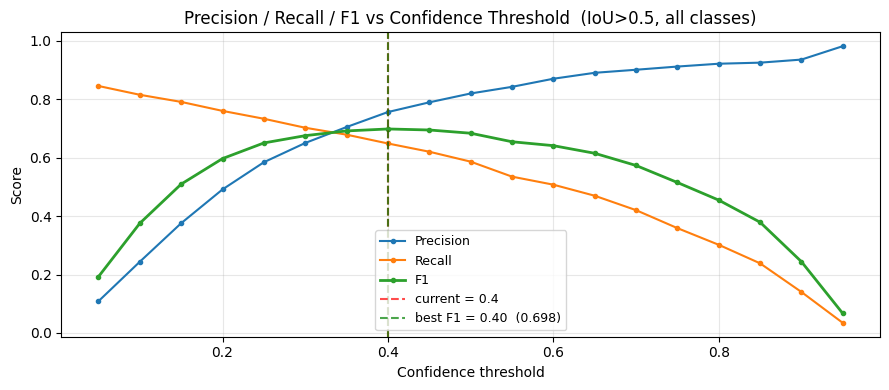

In [9]:
# Precision / Recall / F1 vs confidence threshold
# (mAP already integrates over the full PR curve internally — sweeping thresholds
# for mAP is meaningless. These fixed-threshold metrics are what actually matter
# for choosing an operating point.)

_all_raw = json.load(open(PREDICTIONS_FILE))
thresholds = np.arange(0.05, 0.96, 0.05)
precisions, recalls, f1s = [], [], []

for t in thresholds:
    preds_t = {}
    for p in _all_raw:
        if p["score"] >= t:
            preds_t.setdefault(p["image_id"], []).append(p)

    tp_t = fp_t = fn_t = 0
    for i, img_id in enumerate(img_id_order):
        ps = preds_t.get(img_id, [])
        if ps:
            xyxy   = np.array([[p["bbox"][0], p["bbox"][1],
                                p["bbox"][0]+p["bbox"][2],
                                p["bbox"][1]+p["bbox"][3]] for p in ps], dtype=float)
            cids   = np.array([p["category_id"] for p in ps], dtype=int)
            scores = np.array([p["score"]        for p in ps], dtype=float)
            pred_d = sv.Detections(xyxy=xyxy, class_id=cids, confidence=scores)
        else:
            pred_d = sv.Detections(xyxy=np.empty((0,4),dtype=float),
                                   class_id=np.array([],dtype=int),
                                   confidence=np.array([],dtype=float))

        matched, fn_list, fp_list = match_detections(pred_d, all_gt_dets[i], IOU_THRESH)
        tp_t += len(matched)
        fp_t += len(fp_list)
        fn_t += len(fn_list)

    prec = tp_t / (tp_t + fp_t) if tp_t + fp_t > 0 else 0.0
    rec  = tp_t / (tp_t + fn_t) if tp_t + fn_t > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if prec + rec > 0 else 0.0
    precisions.append(prec); recalls.append(rec); f1s.append(f1)

best_t = thresholds[np.argmax(f1s)]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, precisions, marker="o", ms=3, label="Precision")
ax.plot(thresholds, recalls,    marker="o", ms=3, label="Recall")
ax.plot(thresholds, f1s,        marker="o", ms=3, label="F1", linewidth=2)
ax.axvline(THRESHOLD, color="red",  linestyle="--", alpha=0.7, label=f"current = {THRESHOLD}")
ax.axvline(best_t,   color="green", linestyle="--", alpha=0.7,
           label=f"best F1 = {best_t:.2f}  ({max(f1s):.3f})")
ax.set_xlabel("Confidence threshold")
ax.set_ylabel("Score")
ax.set_title(f"Precision / Recall / F1 vs Confidence Threshold  (IoU>{IOU_THRESH}, all classes)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(SAVE_DIR / "threshold_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 3. FP / FN Analysis

- **Wrong-class crops** — detected at the right location (IoU ≥ IOU_THRESH) but wrong category.
- **FP / FN crops** — side-by-side: top row = spurious predictions, bottom row = missed GT objects.

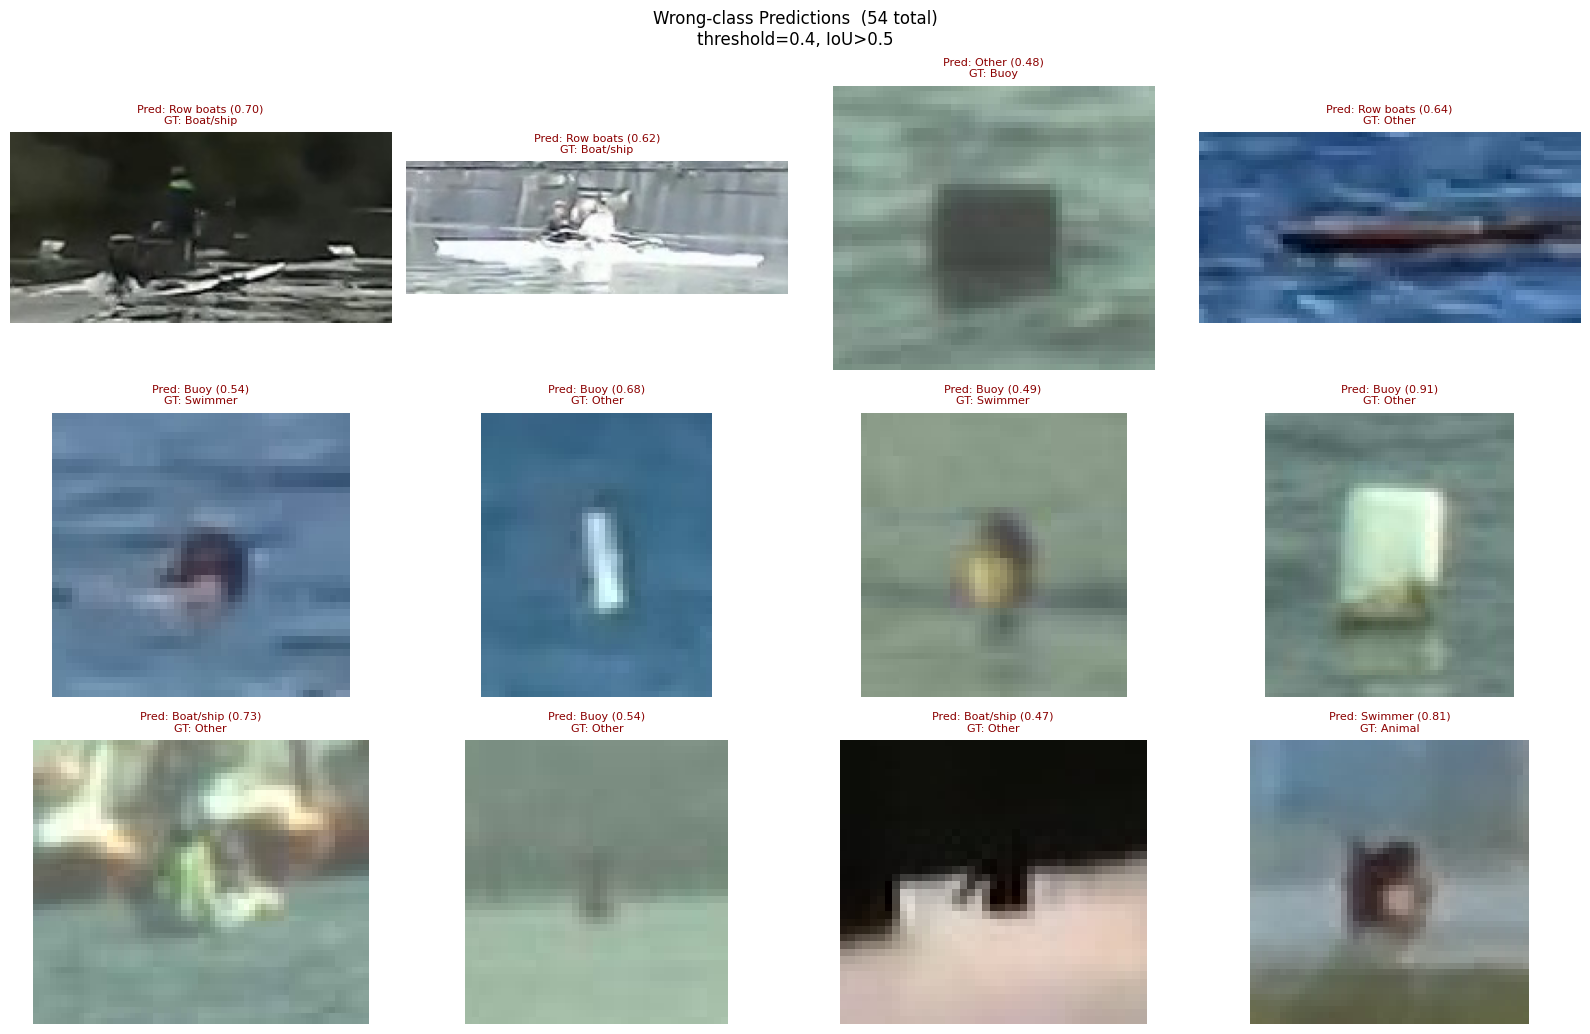

Showing 12 of 54 wrong-class predictions.


In [10]:
def crop_box(arr, box, pad=15):
    h, w = arr.shape[:2]
    x1, y1, x2, y2 = int(box[0]), int(box[1]), int(box[2]), int(box[3])
    return arr[max(0, y1-pad):min(h, y2+pad), max(0, x1-pad):min(w, x2+pad)]


n_show = min(12, len(wrong_class_examples))
if n_show == 0:
    print("No wrong-class predictions found at this threshold / IoU setting.")
else:
    random.seed(4)
    samples = random.sample(wrong_class_examples, n_show)
    cols = 4
    rows = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3.5))
    axes = np.array(axes).reshape(-1)

    for ax, (img_path, pred_box, pred_cls, pred_score, gt_box, gt_cls) in zip(axes, samples):
        arr  = np.array(Image.open(img_path).convert("RGB"))
        crop = crop_box(arr, pred_box)
        ax.imshow(crop)
        ax.set_title(
            f"Pred: {cls_name(pred_cls)} ({pred_score:.2f})\nGT: {cls_name(gt_cls)}",
            fontsize=8, color="darkred"
        )
        ax.axis("off")

    for ax in axes[n_show:]:
        ax.axis("off")

    plt.suptitle(
        f"Wrong-class Predictions  ({len(wrong_class_examples)} total)\n"
        f"threshold={THRESHOLD}, IoU>{IOU_THRESH}",
        fontsize=12
    )
    plt.tight_layout()
    plt.savefig(SAVE_DIR / "wrong_class.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Showing {n_show} of {len(wrong_class_examples)} wrong-class predictions.")

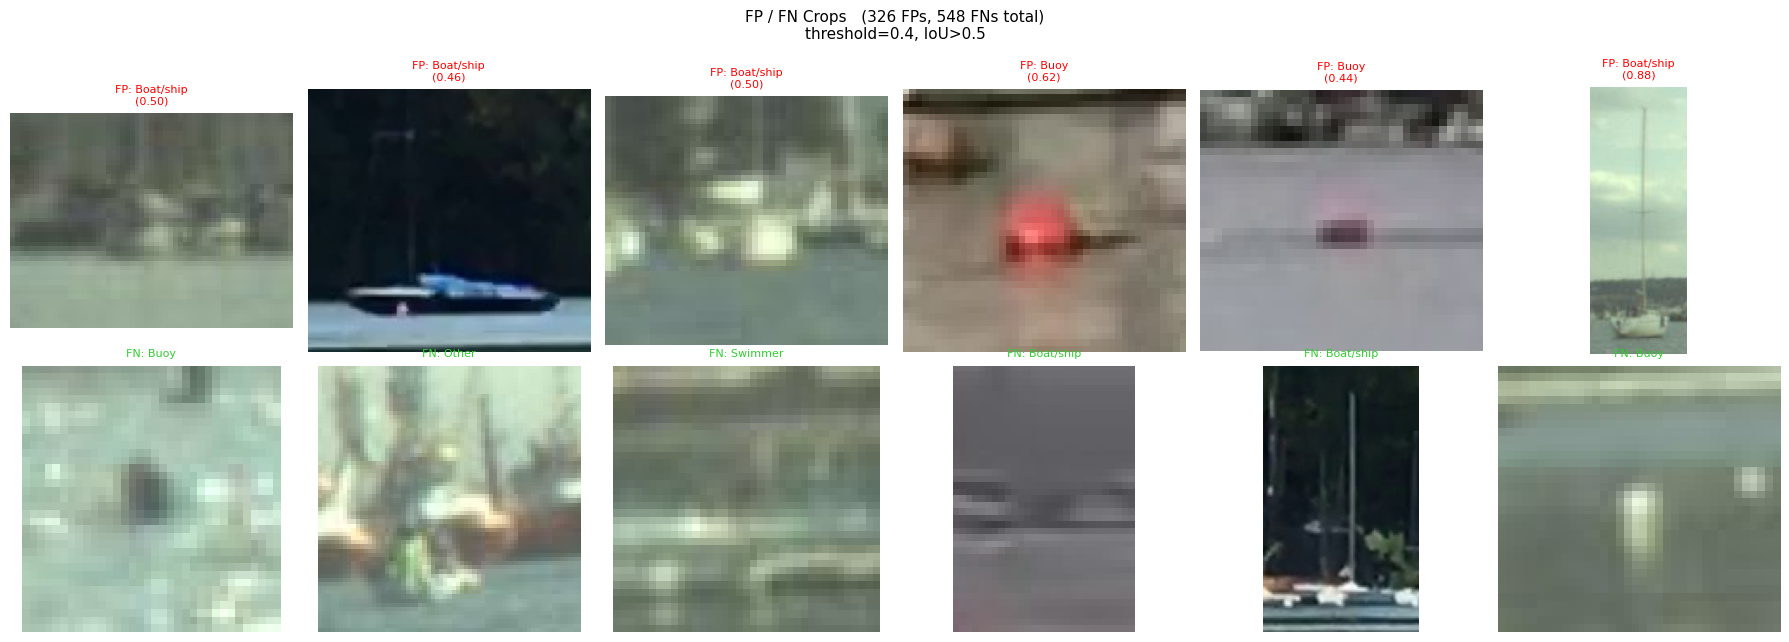

In [11]:
fp_examples = [(p, b, c, s) for p, fps in fp_by_image.items() for b, c, s in fps]
fn_examples = [(p, b, c)    for p, fns in fn_by_image.items() for b, c    in fns]

n_each = 6
random.seed(4)
fp_sample = random.sample(fp_examples, min(n_each, len(fp_examples)))
fn_sample = random.sample(fn_examples, min(n_each, len(fn_examples)))
n_cols    = max(len(fp_sample), len(fn_sample), 1)

fig, axes = plt.subplots(2, n_cols, figsize=(n_cols * 3, 6.5))

for col, (img_path, box, cls, score) in enumerate(fp_sample):
    axes[0, col].imshow(crop_box(np.array(Image.open(img_path).convert("RGB")), box))
    axes[0, col].set_title(f"FP: {cls_name(cls)}\n({score:.2f})", fontsize=8, color="red")
    axes[0, col].axis("off")

for col, (img_path, box, cls) in enumerate(fn_sample):
    axes[1, col].imshow(crop_box(np.array(Image.open(img_path).convert("RGB")), box))
    axes[1, col].set_title(f"FN: {cls_name(cls)}", fontsize=8, color="limegreen")
    axes[1, col].axis("off")

for col in range(len(fp_sample), n_cols): axes[0, col].axis("off")
for col in range(len(fn_sample), n_cols): axes[1, col].axis("off")

axes[0, 0].set_ylabel("FP\n(spurious)", fontsize=9, color="red")
axes[1, 0].set_ylabel("FN\n(missed GT)", fontsize=9, color="limegreen")

plt.suptitle(f"FP / FN Crops   ({len(fp_examples)} FPs, {len(fn_examples)} FNs total)\n"
             f"threshold={THRESHOLD}, IoU>{IOU_THRESH}", fontsize=11)
plt.tight_layout()
plt.savefig(SAVE_DIR / "fp_fn_crops.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 4. Object Size Analysis

Shows how model performance varies with object size.
- **TP** / **FN** use the GT box area; **FP** uses the predicted box area.

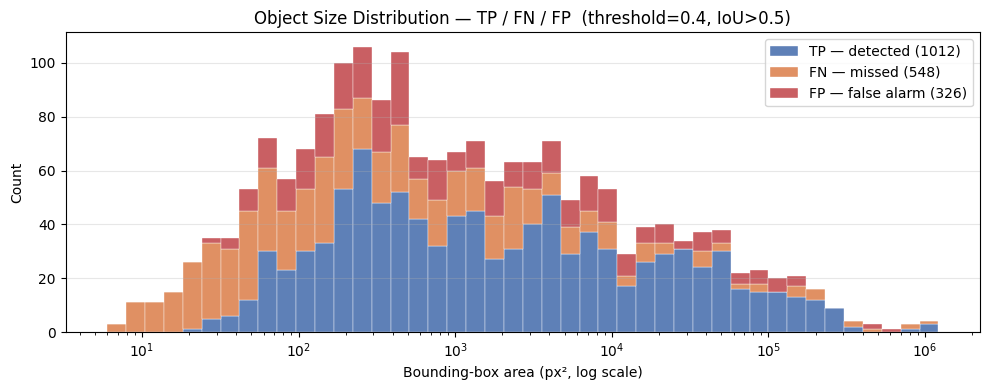

In [12]:
def box_area(box):
    return max(0.0, box[2] - box[0]) * max(0.0, box[3] - box[1])

tp_areas = np.array([box_area(r["gt_box"])   for r in tp_records])
fn_areas = np.array([box_area(r["gt_box"])   for r in fn_records])
fp_areas = np.array([box_area(r["pred_box"]) for r in fp_records])

all_areas = np.concatenate([tp_areas, fn_areas, fp_areas])
bins = np.logspace(np.log10(max(all_areas.min(), 1)), np.log10(all_areas.max()), 45)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist([tp_areas, fn_areas, fp_areas], bins=bins, stacked=True,
        label=[f"TP — detected ({len(tp_areas)})",
               f"FN — missed ({len(fn_areas)})",
               f"FP — false alarm ({len(fp_areas)})"],
        color=["#4C72B0", "#DD8452", "#C44E52"], alpha=0.9, edgecolor="white", linewidth=0.3)

ax.set_xscale("log")
ax.set_xlabel("Bounding-box area (px², log scale)")
ax.set_ylabel("Count")
ax.set_title(f"Object Size Distribution — TP / FN / FP  (threshold={THRESHOLD}, IoU>{IOU_THRESH})")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(SAVE_DIR / "size_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 5. Object Location Analysis

The image is divided into a **3×3 grid** of equal-sized cells.
Each GT/prediction box is assigned to the cell that contains its **centre point**.

- **Recall heatmap** — fraction of GT objects that were detected (TP / (TP+FN)) per cell.
- **FP-density heatmap** — number of spurious predictions per cell.
- **FN-density heatmap** — number of missed GT objects per cell.

Image dimensions are read from the annotation metadata so no images need to be loaded.

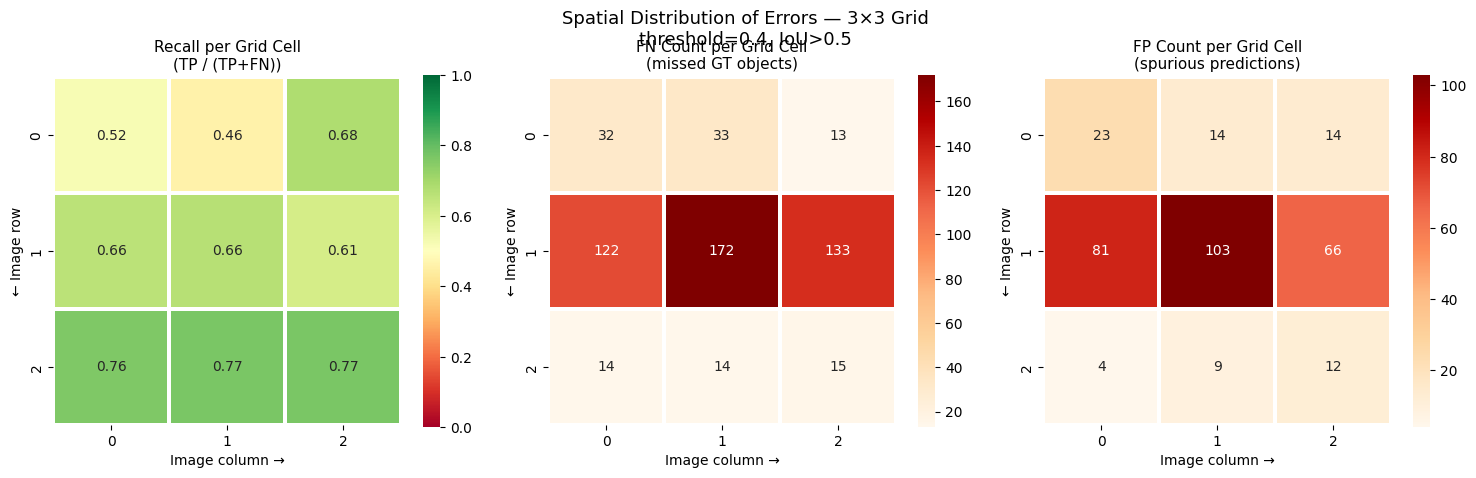

In [13]:
GRID = 3  # NxN grid

def grid_cell(cx_norm, cy_norm, n=GRID):
    col = min(int(cx_norm * n), n - 1)
    row = min(int(cy_norm * n), n - 1)
    return row, col

tp_loc  = np.zeros((GRID, GRID), dtype=int)
fn_loc  = np.zeros((GRID, GRID), dtype=int)
fp_loc  = np.zeros((GRID, GRID), dtype=int)

for r in tp_records:
    meta = img_meta[r["img_id"]]
    W, H = meta["width"], meta["height"]
    box  = r["gt_box"]
    cx   = ((box[0] + box[2]) / 2) / W
    cy   = ((box[1] + box[3]) / 2) / H
    row, col = grid_cell(cx, cy)
    tp_loc[row, col] += 1

for r in fn_records:
    meta = img_meta[r["img_id"]]
    W, H = meta["width"], meta["height"]
    box  = r["gt_box"]
    cx   = ((box[0] + box[2]) / 2) / W
    cy   = ((box[1] + box[3]) / 2) / H
    row, col = grid_cell(cx, cy)
    fn_loc[row, col] += 1

for r in fp_records:
    meta = img_meta[r["img_id"]]
    W, H = meta["width"], meta["height"]
    box  = r["pred_box"]
    cx   = ((box[0] + box[2]) / 2) / W
    cy   = ((box[1] + box[3]) / 2) / H
    row, col = grid_cell(cx, cy)
    fp_loc[row, col] += 1

# Recall per cell
denom     = tp_loc + fn_loc
recall_loc = np.where(denom > 0, tp_loc / denom, np.nan)

# ── Plots ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

kw_base = dict(linewidths=1.5, square=True)

ax = axes[0]
sns.heatmap(
    recall_loc, annot=True, fmt=".2f", cmap="RdYlGn",
    vmin=0, vmax=1, ax=ax,
    mask=np.isnan(recall_loc), **kw_base
)
ax.set_title("Recall per Grid Cell\n(TP / (TP+FN))", fontsize=11)
ax.set_xlabel("Image column →"); ax.set_ylabel("← Image row")

ax = axes[1]
sns.heatmap(fn_loc, annot=True, fmt="d", cmap="OrRd", ax=ax, **kw_base)
ax.set_title("FN Count per Grid Cell\n(missed GT objects)", fontsize=11)
ax.set_xlabel("Image column →"); ax.set_ylabel("← Image row")

ax = axes[2]
sns.heatmap(fp_loc, annot=True, fmt="d", cmap="OrRd", ax=ax, **kw_base)
ax.set_title("FP Count per Grid Cell\n(spurious predictions)", fontsize=11)
ax.set_xlabel("Image column →"); ax.set_ylabel("← Image row")

plt.suptitle(
    f"Spatial Distribution of Errors — {GRID}×{GRID} Grid\n"
    f"threshold={THRESHOLD}, IoU>{IOU_THRESH}",
    fontsize=13
)
plt.tight_layout()
plt.savefig(SAVE_DIR / "location_grid.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 6. Scene Condition Analysis *(LARS-specific — optional)*

Performance broken down by the LARS image-level labels:
**scene type**, **lighting**, **reflections**, **wave** conditions, and special flags.

Requires `../Data/lars_v1.0.0_annotations/{split}/image_annotations.json`.
The cell below skips gracefully if that file is not present.

In [14]:
# ── LARS image-level annotations ─────────────────────────────────────────────
# Combines all three original splits so any custom split works automatically.
LARS_ANN_DIR  = Path("../../Data/lars_v1")
SCENE_FIELDS  = ["scene_type", "lighting", "reflections", "waves"]
SPECIAL_FLAGS = ["extra_dark", "glitter", "wakes", "fog"]

scene_meta = {}
for split in ["train", "val", "test"]:
    f = LARS_ANN_DIR / split / "image_annotations.json"
    if f.exists():
        for a in json.load(open(f))["annotations"]:
            scene_meta[Path(a["file_name"]).name] = a["labels"]

if not scene_meta:
    print(f"LARS annotation files not found under {LARS_ANN_DIR}")
    print("Skipping scene condition analysis.")
    _scene_available = False
else:
    def prf(tp, fp, fn):
        prec = tp / (tp + fp) if tp + fp > 0 else 0.0
        rec  = tp / (tp + fn) if tp + fn > 0 else 0.0
        f1   = 2 * prec * rec / (prec + rec) if prec + rec > 0 else 0.0
        return prec, rec, f1

    per_image = {}
    for i, img_id in enumerate(img_id_order):
        base   = Path(img_meta[img_id]["file_name"]).name
        labels = scene_meta.get(base, {})
        matched_i, fn_i, fp_i = match_detections(
            all_pred_dets[i], all_gt_dets[i], IOU_THRESH
        )
        per_image[base] = {
            "tp": len(matched_i), "fp": len(fp_i), "fn": len(fn_i),
            **{f: str(labels.get(f, "unknown")) for f in SCENE_FIELDS},
            **{f: bool((labels.get("special") or {}).get(f, False)) for f in SPECIAL_FLAGS},
        }

    _scene_available = True
    print(f"Scene metadata loaded for {len(scene_meta)} images across all splits.")
    matched_count = sum(1 for b in per_image.values() if b["scene_type"] != "unknown")
    print(f"  Matched to current eval set: {matched_count} / {len(per_image)}")

Scene metadata loaded for 4006 images across all splits.
  Matched to current eval set: 503 / 503


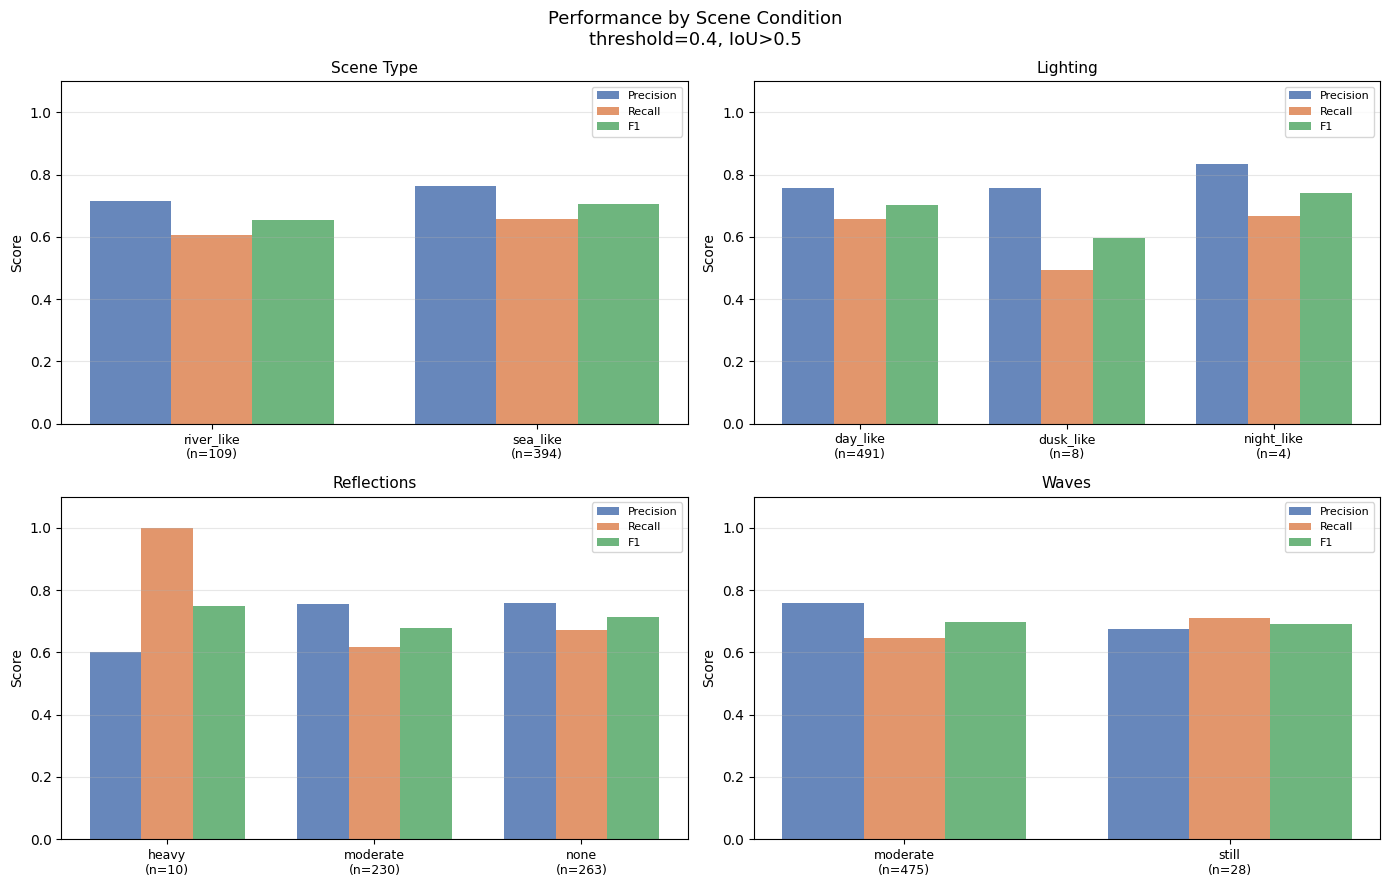

In [15]:
if not _scene_available:
    print("Scene data unavailable — skipping plot.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    axes = axes.flatten()
    COLORS = ["#4C72B0", "#DD8452", "#55A868"]

    for ax, field in zip(axes, SCENE_FIELDS):
        groups = {}
        for r in per_image.values():
            k = r[field]
            g = groups.setdefault(k, {"tp": 0, "fp": 0, "fn": 0, "n": 0})
            g["tp"] += r["tp"]; g["fp"] += r["fp"]; g["fn"] += r["fn"]; g["n"] += 1

        keys = sorted(groups)
        x    = np.arange(len(keys))
        w    = 0.25
        for j, (label, color) in enumerate(zip(["Precision", "Recall", "F1"], COLORS)):
            vals = [prf(groups[k]["tp"], groups[k]["fp"], groups[k]["fn"])[j] for k in keys]
            ax.bar(x + j * w, vals, w, label=label, color=color, alpha=0.85)

        ax.set_xticks(x + w)
        ax.set_xticklabels([f"{k}\n(n={groups[k]['n']})" for k in keys], fontsize=9)
        ax.set_ylim(0, 1.1)
        ax.set_title(field.replace("_", " ").title(), fontsize=11)
        ax.set_ylabel("Score")
        ax.legend(fontsize=8)
        ax.grid(axis="y", alpha=0.3)

    plt.suptitle(
        f"Performance by Scene Condition\nthreshold={THRESHOLD}, IoU>{IOU_THRESH}", fontsize=13
    )
    plt.tight_layout()
    plt.savefig(SAVE_DIR / "scene_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()

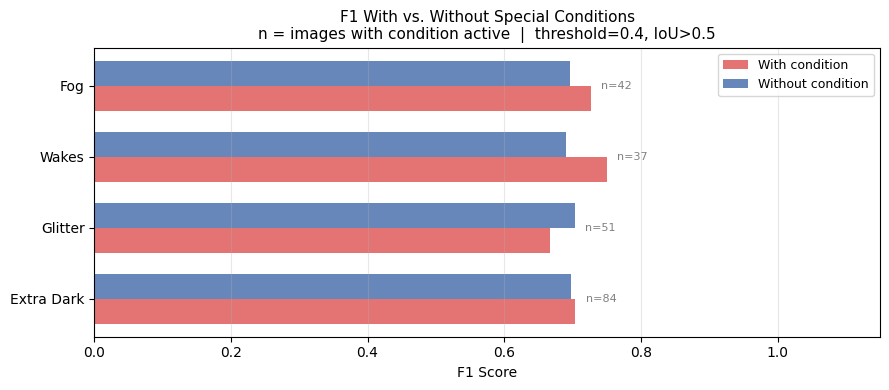

In [16]:
if not _scene_available:
    print("Scene data unavailable — skipping plot.")
else:
    fig, ax = plt.subplots(figsize=(9, 4))
    w = 0.35

    for i, flag in enumerate(SPECIAL_FLAGS):
        with_flag    = [r for r in per_image.values() if r[flag]]
        without_flag = [r for r in per_image.values() if not r[flag]]

        def agg_f1(records):
            tp = sum(r["tp"] for r in records)
            fp = sum(r["fp"] for r in records)
            fn = sum(r["fn"] for r in records)
            return prf(tp, fp, fn)[2]

        f1_with    = agg_f1(with_flag)
        f1_without = agg_f1(without_flag)

        ax.barh(i - w / 2, f1_with,    w, color="#E05C5C", alpha=0.85,
                label="With condition"    if i == 0 else "")
        ax.barh(i + w / 2, f1_without, w, color="#4C72B0", alpha=0.85,
                label="Without condition" if i == 0 else "")
        ax.text(max(f1_with, f1_without) + 0.015, i,
                f"n={len(with_flag)}", va="center", fontsize=8, color="gray")

    ax.set_yticks(range(len(SPECIAL_FLAGS)))
    ax.set_yticklabels([f.replace("_", " ").title() for f in SPECIAL_FLAGS], fontsize=10)
    ax.set_xlim(0, 1.15)
    ax.set_xlabel("F1 Score")
    ax.set_title(
        f"F1 With vs. Without Special Conditions\n"
        f"n = images with condition active  |  threshold={THRESHOLD}, IoU>{IOU_THRESH}",
        fontsize=11
    )
    ax.legend(fontsize=9)
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig(SAVE_DIR / "scene_special.png", dpi=150, bbox_inches="tight")
    plt.show()